# Ablation Study — Single-Channel (z@500) Cyclone Forecasting

**Purpose**: Test whether geopotential height at 500 hPa alone can match the full 13-channel model for direction prediction.

- **Input**: 1-channel 3D fields (z@500), 8 env features, 1D track data (LON, LAT, P, W)
- **Architecture**: CNN + GRU, ~500k params
- **Train**: 1990–2012 | **Val**: 2013–2016 | **Test**: 2017–2023
- **Loss**: Unweighted CrossEntropy (no class balancing — intentional for comparison)


In [7]:
import os, torch, torch.nn as nn, torch.optim as optim
import numpy as np, pandas as pd, math, glob, matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from netCDF4 import Dataset as ncDataset
from natsort import natsorted

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_PATH = r"C:\Users\danie\Desktop\Tropical Cyclones"
AREA = "WP"

Z_MEAN, Z_STD = 5500.0, 500.0

SAFE_ENV_KEYS = ['area', 'wind', 'intensity_class', 'move_velocity', 'month', 
                 'location_long', 'location_lat', 'history_direction24']

print(f"Device: {DEVICE}")

Device: cuda


In [9]:
class CycloneDataset(Dataset):
    def __init__(self, splits='train', target_years=None, seq_len=5, use_env=True, use_3d=True):
        self.seq_len, self.use_env, self.use_3d = seq_len, use_env, use_3d
        self.samples = []
        
        path_1d_root = os.path.join(BASE_PATH, "TCND_Data1D", "Data1D", AREA)
        path_3d_root = os.path.join(BASE_PATH, "TCND_Data3D_WP", AREA)
        path_env_root = os.path.join(BASE_PATH, "TCND_Env-Data", "Env-Data", AREA)


        if isinstance(splits, str): splits = [splits]
        
        for split in splits:
            # Data/Data1D/WP/train/*.txt
            search_path = os.path.join(path_1d_root, split, "*.txt")
            files = natsorted(glob.glob(search_path))
            
            if not files:
                print(f"No files found")
                continue

            for f in files:
                file_year = int(os.path.basename(f)[2:6])
                if target_years and file_year not in target_years: 
                    continue
                
                df = pd.read_csv(f, delimiter='\t', header=None, names=['ID','F','LON','LAT','P','W','TIME','Name'])
                if len(df) < seq_len + 1: 
                    continue
                name = str(df.iloc[0]['Name']).strip()

                for i in range(seq_len - 1, len(df) - 1):
                    curr_seq = df.iloc[i-seq_len+1 : i+1]
                    ts_list = [str(int(row['TIME'])) for _, row in curr_seq.iterrows()]
                    t_last = ts_list[-1]

                    env_p_label = os.path.join(path_env_root, t_last[:4], name, f"{t_last}.npy")
                    if not os.path.exists(env_p_label): 
                        continue
                    
                    try:
                        data_npy = np.load(env_p_label, allow_pickle=True).item()
                        y_dir = data_npy.get('future_direction24')
                        y_int = data_npy.get('future_inte_change24')
                        
                        if y_dir is None or y_int is None: 
                            continue
                        y_dir, y_int = int(y_dir), int(y_int)
                        if not (0 <= y_dir <= 7) or not (0 <= y_int <= 3): 
                            continue
                        
                        self.samples.append({
                            'feat1d': curr_seq[['LON','LAT','P','W']].values.astype(np.float32),
                            'env_paths': [os.path.join(path_env_root, t[:4], name, f"{t}.npy") for t in ts_list],
                            'nc_paths': [os.path.join(path_3d_root, t[:4], name, f"TCND_{name}_{t}_sst_z_u_v.nc") for t in ts_list],
                            'y_dir': y_dir, 'y_int': y_int
                        })
                    except Exception: continue

        print(f"Dataset Loaded: {len(self.samples)} samples")

    def __len__(self): 
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        f1d = torch.from_numpy(s['feat1d'])
        
        # 3D Data
        f3d = torch.zeros((self.seq_len, 1, 81, 81))
        if self.use_3d:
            imgs = []
            for p in s['nc_paths']:
                if not os.path.exists(p):
                    imgs.append(np.zeros((81, 81))) 
                    continue
                with ncDataset(p) as nc:
                    imgs.append((nc.variables['z'][0, 1, :, :] - 5500.0) / 500.0)
            f3d = torch.from_numpy(np.stack(imgs)).unsqueeze(1).float()

        # Env Data
        f_env = torch.zeros((self.seq_len, len(SAFE_ENV_KEYS))) 
        if self.use_env:
            vecs = []
            for p in s['env_paths']:
                if not os.path.exists(p):
                    vecs.append(np.zeros(len(SAFE_ENV_KEYS)))
                    continue
                d = np.load(p, allow_pickle=True).item()
                row_vec = [float(np.array(d.get(k, 0.0)).flatten()[0]) for k in SAFE_ENV_KEYS]
                vecs.append(np.array(row_vec))
            f_env = torch.from_numpy(np.stack(vecs)).float()

        return f3d, f_env, f1d, torch.tensor(s['y_dir']).long(), torch.tensor(s['y_int']).long()

In [4]:
class CycloneFusionNet(nn.Module):
    def __init__(self, env_dim, hidden_dim=256):
        super(CycloneFusionNet, self).__init__()
        self.spatial_cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2)), nn.Flatten()
        )
        self.vec_proj = nn.Linear(env_dim + 4, 128)
        self.gru = nn.GRU(input_size=512 + 128, hidden_size=hidden_dim, num_layers=2, batch_first=True, dropout=0.3)
        self.dir_head = nn.Sequential(nn.Linear(hidden_dim, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 8))
        self.int_head = nn.Sequential(nn.Linear(hidden_dim, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 4))

    def forward(self, x3d, x_env, x1d):
        b, t, c, h, w = x3d.size()
        s_out = self.spatial_cnn(x3d.view(b * t, c, h, w)).view(b, t, -1)
        v_out = self.vec_proj(torch.cat([x_env, x1d], dim=-1))
        r_out, _ = self.gru(torch.cat([s_out, v_out], dim=-1))
        feat = r_out[:, -1, :] 
        return self.dir_head(feat), self.int_head(feat)

Dataset Loaded: 11488 samples
Dataset Loaded: 1531 samples
Training Started
Epoch 01 | Loss: 2.378/1.937 | DirAcc(V): 59.83% | IntAcc(V): 70.22% | LR: 0.0001
New Best Model Saved
Epoch 02 | Loss: 1.903/1.787 | DirAcc(V): 60.94% | IntAcc(V): 71.00% | LR: 0.0001
New Best Model Saved
Epoch 03 | Loss: 1.780/1.648 | DirAcc(V): 65.25% | IntAcc(V): 72.96% | LR: 0.0001
New Best Model Saved
Epoch 04 | Loss: 1.718/1.612 | DirAcc(V): 66.95% | IntAcc(V): 72.04% | LR: 0.0001
New Best Model Saved
Epoch 05 | Loss: 1.677/1.597 | DirAcc(V): 67.08% | IntAcc(V): 74.20% | LR: 0.0001
New Best Model Saved
Epoch 06 | Loss: 1.645/1.586 | DirAcc(V): 67.60% | IntAcc(V): 72.70% | LR: 0.0001
Epoch 07 | Loss: 1.620/1.610 | DirAcc(V): 67.60% | IntAcc(V): 71.26% | LR: 0.0001
Epoch 08 | Loss: 1.606/1.561 | DirAcc(V): 68.13% | IntAcc(V): 72.76% | LR: 0.0001
Epoch 09 | Loss: 1.583/1.538 | DirAcc(V): 68.91% | IntAcc(V): 72.76% | LR: 0.0001
New Best Model Saved
Epoch 10 | Loss: 1.564/1.537 | DirAcc(V): 69.24% | IntAcc(V)

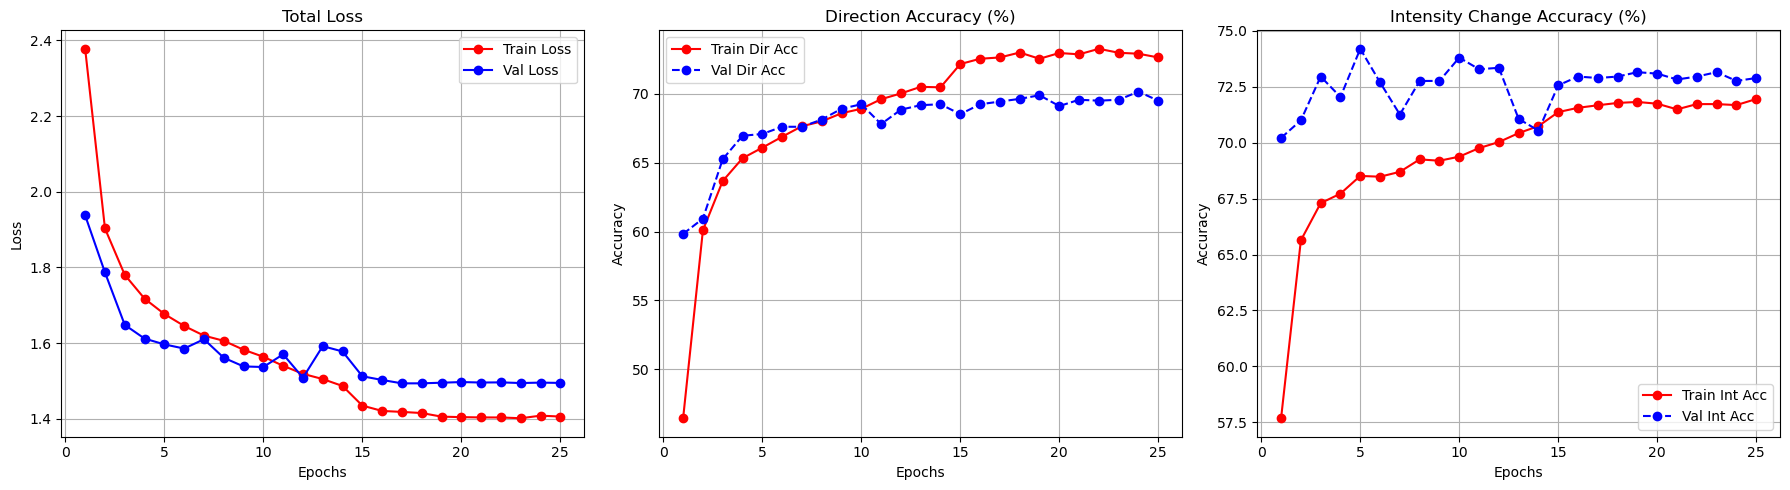

In [ ]:
import matplotlib.pyplot as plt

# Hyperparameters
TRAIN_YEARS  = list(range(1950, 2013))
VAL_YEARS    = list(range(2013, 2017)) 
BATCH_SIZE   = 32
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 0.05
EPOCHS       = 100
PATIENCE     = 3           
EARLY_STOP_PATIENCE = 15  

def main():
    train_ds = CycloneDataset(splits='train', target_years=TRAIN_YEARS)
    val_ds = CycloneDataset(splits='val', target_years=VAL_YEARS)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    _, s_env, _, _, _ = train_ds[0]
    model = CycloneFusionNet(env_dim=s_env.shape[-1]).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=PATIENCE)

    history = {
        'train_loss': [], 'val_loss': [],
        't_dir_acc': [], 't_int_acc': [],
        'v_dir_acc': [], 'v_int_acc': [],
        'lrs': []
    }
    
    best_avg_acc = 0.0
    early_stop_counter = 0 
    
    print(f"Training Started")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        t_loss, td_ok, ti_ok, t_total = 0, 0, 0, 0
        for x3d, xenv, x1d, yd, yi in train_loader:
            x3d, xenv, x1d, yd, yi = [item.to(DEVICE) for item in [x3d, xenv, x1d, yd, yi]]
            
            optimizer.zero_grad()
            pd, pi = model(x3d, xenv, x1d)
            loss = criterion(pd, yd) + criterion(pi, yi)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            t_loss += loss.item()
            td_ok += (pd.argmax(1) == yd).sum().item()
            ti_ok += (pi.argmax(1) == yi).sum().item()
            t_total += yd.size(0)

        # Validation
        model.eval()
        v_loss, vd_ok, vi_ok, v_total = 0, 0, 0, 0
        with torch.no_grad():
            for x3d, xenv, x1d, yd, yi in val_loader:
                x3d, xenv, x1d, yd, yi = [item.to(DEVICE) for item in [x3d, xenv, x1d, yd, yi]]
                pd, pi = model(x3d, xenv, x1d)
                loss = criterion(pd, yd) + criterion(pi, yi)
                
                v_loss += loss.item()
                vd_ok += (pd.argmax(1) == yd).sum().item()
                vi_ok += (pi.argmax(1) == yi).sum().item()
                v_total += yd.size(0)

        train_loss = t_loss / len(train_loader)
        val_loss = v_loss / len(val_loader)
        
        t_dir_acc = 100 * td_ok / t_total
        t_int_acc = 100 * ti_ok / t_total
        v_dir_acc = 100 * vd_ok / v_total
        v_int_acc = 100 * vi_ok / v_total
        
        avg_v_acc = (v_dir_acc + v_int_acc) / 2
        current_lr = optimizer.param_groups[0]['lr']

        # history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['t_dir_acc'].append(t_dir_acc)
        history['t_int_acc'].append(t_int_acc)
        history['v_dir_acc'].append(v_dir_acc)
        history['v_int_acc'].append(v_int_acc)
        history['lrs'].append(current_lr)

        print(f"Epoch {epoch:02d} | Loss: {train_loss:.3f}/{val_loss:.3f} | "
              f"DirAcc(V): {v_dir_acc:.2f}% | IntAcc(V): {v_int_acc:.2f}% | LR: {current_lr}")

        scheduler.step(avg_v_acc)
        
        if avg_v_acc > best_avg_acc:
            best_avg_acc = avg_v_acc
            early_stop_counter = 0
            torch.save(model.state_dict(), "best_task_model.pth")
            print(f"New Best Model Saved")
        else:
            early_stop_counter += 1

        if early_stop_counter >= EARLY_STOP_PATIENCE:
            print(f"Early stopping")
            break

    plot_multi_task_history(history)

def plot_multi_task_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(18, 5))

    # 1. Loss curve
    plt.subplot(1, 3, 1)
    plt.plot(epochs, history['train_loss'], 'r-o', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'b-o', label='Val Loss')
    plt.title('Total Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 2. Direction Acc
    plt.subplot(1, 3, 2)
    plt.plot(epochs, history['t_dir_acc'], 'r-o', label='Train Dir Acc')
    plt.plot(epochs, history['v_dir_acc'], 'b--o', label='Val Dir Acc')
    plt.title('Direction Accuracy (%)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # 3. Intensity Acc
    plt.subplot(1, 3, 3)
    plt.plot(epochs, history['t_int_acc'], 'r-o', label='Train Int Acc')
    plt.plot(epochs, history['v_int_acc'], 'b--o', label='Val Int Acc')
    plt.title('Intensity Change Accuracy (%)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()

Dataset Loaded: 3402 samples


C:\Users\danie\AppData\Local\Temp\ipykernel_36704\3108151574.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  eval_model.load_state_dict(torch.load(model_weights, map_lo

Direction Accuracy: 66.55%
Intensity Accuracy: 66.75%


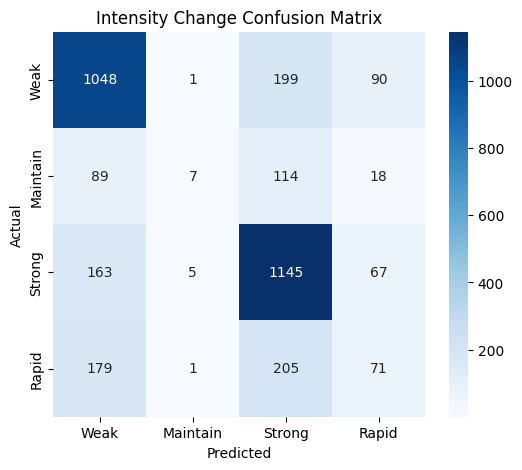

In [15]:
import matplotlib.animation as animation
from IPython.display import HTML
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

test_years = list(range(2017, 2024)) 
frame_number = 50 
frame_name = "typhoon_prediction_final.gif"
model_weights = "classification/saved_models/best_task_model.pth"

def get_arrow_components(label):
    # 0:N, 1:NE, 2:E, 3:SE, 4:S, 5:SW, 6:W, 7:NW
    mapping = {0: 90, 1: 45, 2: 0, 3: 315, 4: 270, 5: 225, 6: 180, 7: 135}
    rad = np.deg2rad(mapping.get(label, 0))
    return np.cos(rad), np.sin(rad)

def final_evaluation():
    test_ds = CycloneDataset(splits='test', target_years=test_years)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
    
    _, s_env, _, _, _ = test_ds[0]
    eval_model = CycloneFusionNet(env_dim=s_env.shape[-1]).to(DEVICE)
    
    if os.path.exists(model_weights):
        eval_model.load_state_dict(torch.load(model_weights, map_location=DEVICE))
    else:
        print(f"{model_weights} not found.")

    eval_model.eval()

    all_yd_true, all_yd_pred = [], []
    all_yi_true, all_yi_pred = [], []
    eval_data_for_gif = []

    with torch.no_grad():
        for b_idx, (x3d, xenv, x1d, yd, yi) in enumerate(test_loader):
            x3d_gpu, xenv_gpu, x1d_gpu = x3d.to(DEVICE), xenv.to(DEVICE), x1d.to(DEVICE)
            pd_logits, pi_logits = eval_model(x3d_gpu, xenv_gpu, x1d_gpu)
            
            p_dir = pd_logits.argmax(1).cpu().numpy()
            p_int = pi_logits.argmax(1).cpu().numpy()
            
            all_yd_true.extend(yd.numpy())
            all_yd_pred.extend(p_dir)
            all_yi_true.extend(yi.numpy())
            all_yi_pred.extend(p_int)
            
            if len(eval_data_for_gif) < frame_number:
                for i in range(len(yd)):
                    if len(eval_data_for_gif) < frame_number:
                        eval_data_for_gif.append((
                            x3d[i, -1, 0].numpy(), 
                            yd[i].item(), 
                            p_dir[i], 
                            yi[i].item(), 
                            p_int[i]
                        ))

    dir_acc = accuracy_score(all_yd_true, all_yd_pred) * 100
    int_acc = accuracy_score(all_yi_true, all_yi_pred) * 100
    print(f"Direction Accuracy: {dir_acc:.2f}%")
    print(f"Intensity Accuracy: {int_acc:.2f}%")

    cm_int = confusion_matrix(all_yi_true, all_yi_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_int, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Weak', 'Maintain', 'Strong', 'Rapid'],
                yticklabels=['Weak', 'Maintain', 'Strong', 'Rapid'])
    plt.title("Intensity Change Confusion Matrix")
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(eval_data_for_gif[0][0], cmap='RdYlBu_r', origin='lower')
    plt.colorbar(im, label="Z500 Geopotential Height (Normalized)")

    qt = ax.quiver(40, 40, 0, 0, color='green', scale=5, label='Actual Direction', headwidth=5)
    qp = ax.quiver(40, 40, 0, 0, color='black', scale=5, label='Predicted Direction', alpha=0.7, headwidth=3)
    ax.legend(loc='upper right')

    def update(i):
        img, td, pd, ti, pi = eval_data_for_gif[i]
        im.set_array(img)
        
        tu, tv = get_arrow_components(td)
        pu, pv = get_arrow_components(pd)
        qt.set_UVC(tu, tv)
        qp.set_UVC(pu, pv)
        
        int_map = {0:'Weak', 1:'Maintain', 2:'Strong', 3:'Rapid'}
        dir_stat = "OK" if td == pd else "WRONG"
        
        ax.set_title(f"Frame {i} | Dir: {dir_stat} | Int True:{int_map[ti]} vs Pred:{int_map[pi]}", 
                     color='green' if (td==pd and ti==pi) else 'darkorange', fontsize=10)
        return [im, qt, qp]

    ani = animation.FuncAnimation(fig, update, frames=len(eval_data_for_gif), interval=800, blit=True)
    ani.save(frame_name, writer='pillow')
    plt.close()
    
    display(HTML(f'<h3>Typhoon Prediction Visualization</h3><img src="{frame_name}" width="500"/>'))

if __name__ == '__main__':
    final_evaluation()